# Building Linear Regression Model from Scratch

## Importing Libraries

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [49]:
X = np.array([850, 900, 1200, 1500, 2000]) # area of house in sq meters
y = np.array([94500, 96000, 133500, 158000, 213000]) # price of house in dollars

## Feature Scaling

In [50]:
x_mean = np.mean(X)
x_std = np.std(X)
y_mean = np.mean(y)
y_std = np.std(y)
x_scaled = (X - x_mean) / x_std
y_scaled = (y - y_mean) / y_std
x_scaled, y_scaled

(array([-1.03593954, -0.91821914, -0.21189672,  0.49442569,  1.67162971]),
 array([-1.01050278, -0.97644089, -0.1248936 ,  0.43145062,  1.68038664]))

## Plotting Data

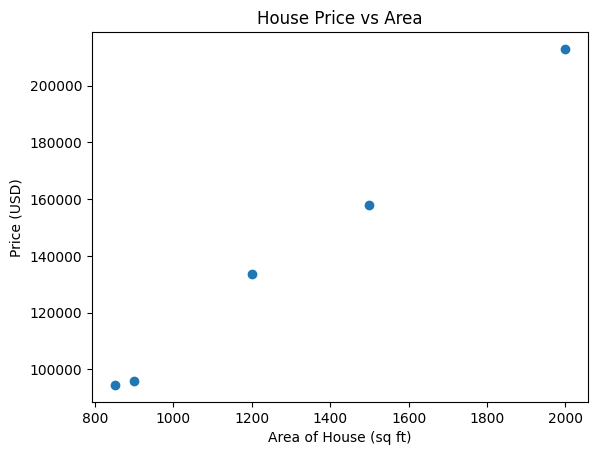

In [51]:
plt.scatter(X, y)
plt.ylabel("Price (USD)")
plt.xlabel("Area of House (sq ft)")
plt.title("House Price vs Area")
plt.show()

## Splitting Data

In [52]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y_scaled, test_size=0.2)

## Computing Cost

In [61]:
def compute_cost(x, y, w, b):
    m = len(x)
    cost_sum = 0
    
    for i in range(m):
        f_wb = x[i] * w + b
        cost_sum += (f_wb - y[i]) ** 2
    
    cost_sum /= (2 * m)
    return cost_sum

## Computing gradient; to be subtracted from alpha later

In [63]:
def compute_gradient(x, y, w, b):
    m = len(x)
    dc_dw = 0
    dc_db = 0

    for i in range(m):
        f_wb = x[i] * w + b

        dc_dw += (f_wb - y[i]) * x[i]
        dc_db += (f_wb - y[i])

    dc_dw /= m
    dc_db /= m

    return dc_dw, dc_db

## Building Gradient Descent

In [64]:
def gradient_descent(x, y, alpha, iterations):
    w = 0
    b = 0

    for i in range(iterations):
        dc_dw, dc_db = compute_gradient(x, y, w, b)

        w -= alpha * dc_dw
        b -= alpha * dc_db

        if i % (iterations // 10) == 0 or i == iterations - 1:
            cost = compute_cost(x, y, w, b)
            print(f"Iteration {i}: Cost {cost:.4f}")
    
    return w, b

## Implementing the gradient descent algorithm  to get the optimum `w` (weight) and `b` (bias) for the function

In [73]:
learning_rate = 0.1
iterations = 100

final_w, final_b = gradient_descent(X_train, y_train, learning_rate, iterations)
print(f"w: {final_w}, b: {final_b}")

Iteration 0: Cost 0.3994
Iteration 10: Cost 0.0544
Iteration 20: Cost 0.0110
Iteration 30: Cost 0.0037
Iteration 40: Cost 0.0022
Iteration 50: Cost 0.0019
Iteration 60: Cost 0.0019
Iteration 70: Cost 0.0018
Iteration 80: Cost 0.0018
Iteration 90: Cost 0.0018
Iteration 99: Cost 0.0018
w: 1.0066005532471682, b: -0.007883691050997888


# Plotting the Linear line the model has learned from gradient descent

- First I created an equally distributed array from `np.linspace` which has `x.min` as minimum and `x.max` as maximum and has 100 values that are equally distantanced from each other.
-  Then I applied the function using learned `w` and `b` from the model.
-  In the last I have plotted the Line using this data.

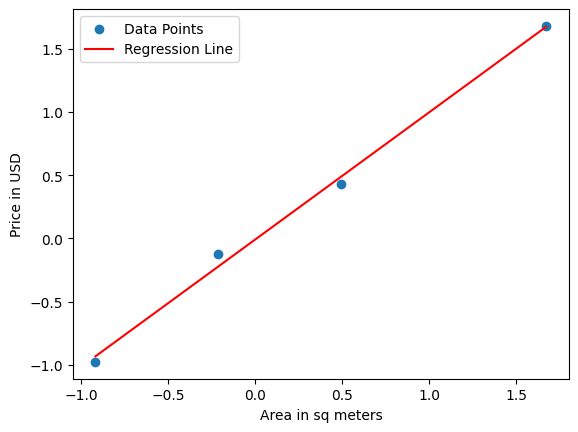

In [74]:
plt.scatter(X_train, y_train, label="Data Points")

x_vals = np.linspace(min(X_train), max(X_train), 100)
y_vals = final_w * x_vals + final_b
plt.plot(x_vals, y_vals, color='red', label='Regression Line')
plt.xlabel("Area in sq meters")
plt.ylabel("Price in USD")
plt.legend()
plt.show()